# [Лекция 12. Реляционные базы данных](https://colab.research.google.com/drive/1nWJfQsjupR6TYtfu2lxRFhBW37OtUISv)

Наступление эпохи Big Data, развитие сложных методик обработки данных, таких как "машинное обучение", было бы невозможно без предварительного накопления человечеством самих этих данных.
Данные собираются, хранятся и обрабатываются в специальных компьютерных **базах данных**.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Введение и основные концепции

### База данных

**База данных** (БД) — это главная часть информационной системы предприятия или организации.
Она представляет из себя совместно используемый набор *логически связанных данных*, а также описание этих данных (*метаданные*).

Данные в БД могут быть структурированы по-разному — согласно одной из *моделей данных*.

Для **реляционных баз данных** основой является *реляционная модель данных*. Слово *relation* значит *отношение*, "реляция", и оно точно описывает внутреннюю структуру таких БД, но чаще такие БД называют *табличными*, а отношение воспринимают как таблицу, хотя это и не совсем корректно.

**Отношение** (таблица) состоит из **кортежей** (строк), которые имеют однотипные **атрибуты** (столбцы). При этом один или несколько атрибутов считаются **первичным ключом**, который должен быть уникален для всех кортежей фактически присутствующих в таблице.

Поиск кортежа по первичному ключу является базовой операцией. Возникающая функциональная зависимость между значением ключа и значениями атрибутов, найденных по ключу, и даёт название "реляции" таким БД.

### Система управления базами данных (СУБД)

База данных организации должна доступной одновременно для всех отделений организации и работать круглосуточно 24х7, а значит быть *сетевой*. Обычно доступ к ней организуют через сеть Интернет.

Если БД находится на одном центральном сервере, то её называют *централизованной*. А если на распределённой системе серверов, то БД называют *распределённой*. Естественно, такие сервера должны работать согласованно друг с другом, чтобы база данных не потеряла своей *целостности*.

Иногда БД может понадобиться даже в рамках одного компьютера (и даже одной программы) — тогда она называется *локальной*.

**Система управления базами данных** — это программное обеспечение, которое позволяет создать базу данных и манипулировать данными (вставлять, обновлять, удалять и выбирать). Она также обеспечивает информационную безопасность, надёжность хранения и целостность данных, а также предоставляет средства для администрирования БД.

Если вы занимались веб-дизайном, то вам поможет аналогия: как сайт относится к веб-серверу, так и БД относится к СУБД. Сайт — это HTML файлы, картинки, стили и скрипты, а веб-сервер — это ПО (Apache, nginx, Lighttpd и др.), которое непрерывно работает для обслуживания клиентов вашего сайта по протоколу HTTP и выдачи им страниц. Один и тот же сайт можно развернуть при помощи разных веб-серверов, хотя для этого могут потребоваться определённые усилия.

Одна и та же БД может быть развёрнута на разных СУБД, хотя для её переноса с одной на другую могут потребоваться усилия.

#### Рейтинг СУБД на декабрь 2024 (по поисковым запросам)

Возьмём рейтинг с сайта https://db-engines.com/en/ranking_trend
и приведём его [в удобную форму файла CSV](https://drive.google.com/file/d/1kI6psyx-OJ1WwjVKHrDY2aU1DjCXC0dM/view?usp=drive_link)

In [ ]:
dbms_rating = pd.read_csv("dbms_rating_2024.12.csv", index_col='No')
dbms_rating

,DBMS,Database_Model,Dec_2024,Nov_2024,Dec_2023
No,,,,,
1,Oracle,"Relational, Multi-model",1263.79,-53.22,6.38
2,MySQL,"Relational, Multi-model",1003.76,-14.04,-122.88
3,Microsoft SQL Server,"Relational, Multi-model",805.69,5.88,-98.14
4,PostgreSQL,"Relational, Multi-model",666.37,12.04,15.47
5,MongoDB,"Document, Multi-model",400.39,-0.54,-18.76
6,Redis,"Key-value, Multi-model",150.27,1.63,-8.08
7,Snowflake,Relational,147.36,4.87,27.48
8,Elasticsearch,Multi-model,132.32,0.68,-5.43
9,IBM Db2,"Relational, Multi-model",122.78,1.04,-11.81


<BarContainer object of 15 artists>

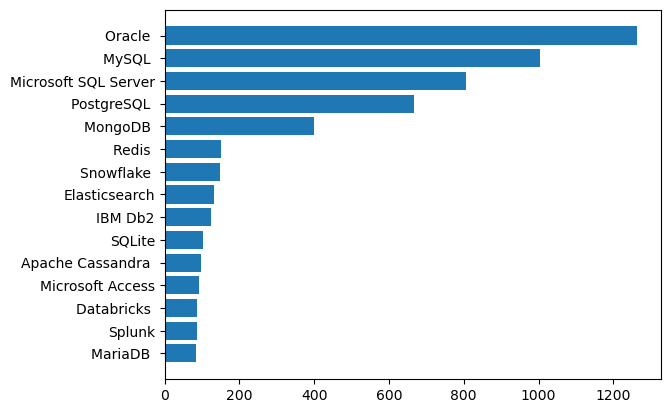

In [ ]:
plt.barh(dbms_rating.DBMS[::-1], dbms_rating.Dec_2024[::-1])

В данном списке есть как коммерческие ("проприетарные"), так и свободные программы.
В частности, Oracle, IBM Db2, Microsoft SQL Server и Microsoft Access — ПО с закрытым кодом и ограничивающей лицензией.

Самые популярные свободные реляционные СУБД:

1. MySQL
2. PostgreSQL
3. Snowflake
4. SQLite
5. MariaDB

Самая простая из них — [локальная СУБД SQLite](https://www.sqlite.org). Она даже не требует отдельной установки, поскольку является встраиваемым модулем.

 ### Реляционная таблица в сравнении с таблицей DataFrame

Таблица (отношение) реляционной БД похожа на лист с данными DataFrame. Однако, отношение обладает большей строгостью, чем DataFrame.
* Столбцы в реляционной таблице также имеют имена и тип, но типизация строгая.
* Первичный ключ подобен индексу-метке строки, но дубликаты исключены.
* В реляционной таблице нет порядка следования строк, числового индекса не существует в принципе.

## Чтение данных из локальной БД SQLite в Pandas DataFrame

Модуль `sqlite3` стандартной библиотеки Python предназначен для работы с локальной СУБД SQLite.

In [ ]:
import sqlite3

База данных для этой СУБД хранится на диске в виде файла с расширением `.db`. Скачаем файл тестовой БД:

In [ ]:
# !wget https://drive.google.com/uc?export=download&id=1mIt_sGEedHGHrmt0GrftfVNkMbicbTBZ
import urllib.request
urllib.request.urlretrieve("https://drive.google.com/uc?export=download&id=1mIt_sGEedHGHrmt0GrftfVNkMbicbTBZ", "ege2023_task3.db")

('ege2023_task3.db', <http.client.HTTPMessage at 0x7f1ccffe97f0>)

Данная БД сгенерирована на основе данных из задачи №3 демонстрационного варианта ЕГЭ по информатике 2023 года. Изменены только названия таблиц.

В файле приведён фрагмент базы данных «Продукты» о поставках товаров в магазины районов города. База данных состоит из трёх таблиц.
1. Таблица **`movement`** («Движение товаров») содержит записи о поставках товаров в магазины в течение первой декады июня 2021 г., а также информацию о проданных товарах. Поле `Тип операции` содержит значение `Поступление` или `Продажа`, а в соответствующее поле `Количество упаковок` внесена информация о том, сколько упаковок товара поступило в магазин или было продано в течение дня.
2. Таблица **`goods`** («Товары») содержит информацию об основных характеристиках каждого товара.
3. Таблица **`stores`** («Магазины») содержит информацию о местонахождении магазинов.

На рисунке приведена схема этой базы данных:
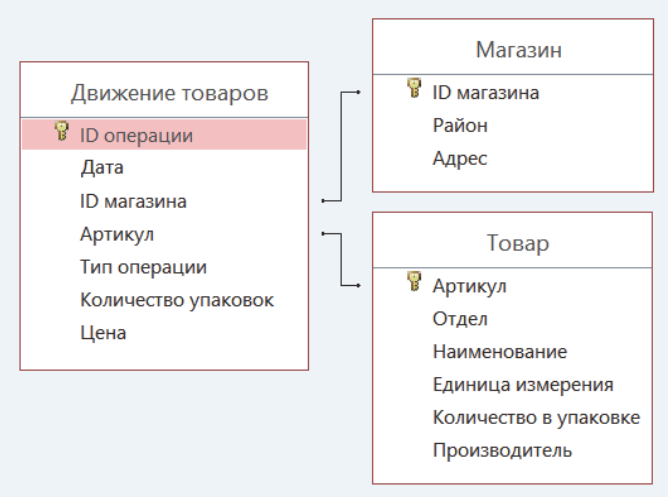

Чтобы работать с БД нужен объект `Connection`, олицетворяющий в нашем коде соединение с БД:

In [ ]:
con = sqlite3.connect("ege2023_task3.db")
con

Теперь для чтения таблиц достаточно вызвать функцию библиотеки Pandas `read_sql`, передав ей ссылку на этот объект `Connection` и конкретный запрос к БД, который мы хотим считать в `DataFrame`:

In [ ]:
movement = pd.read_sql("SELECT * FROM movement", con, index_col="ID операции")
stores = pd.read_sql("SELECT * FROM stores", con, index_col="ID магазина")
goods = pd.read_sql("SELECT * FROM goods", con, index_col="Артикул")

Посмотрим на небольшие выборки данных из этих таблиц:

In [ ]:
movement.sample(3)

,Дата,ID магазина,Артикул,Тип операции,Количество упаковок,Цена
ID операции,,,,,,
1931,07.06.2021,M7,50,Поступление,170,195
2134,08.06.2021,M15,4,Продажа,36,75
381,01.06.2021,M3,5,Поступление,180,70


In [ ]:
stores.sample(3)

,Район,Адрес
ID магазина,,
M15,Октябрьский,"Пушкинская, 8"
M1,Октябрьский,"просп. Мира, 45"
M10,Октябрьский,"пл. Революции, 1"


In [ ]:
goods.sample(3)

,Отдел,Наименование,Единица измерения,Количество в упаковке,Производитель
Артикул,,,,,
31,Бакалея,Лапша гречневая,кг,0.5,Экопродукты
43,Бакалея,Сода пищевая,кг,0.5,Продбаза
30,Бакалея,Сахар рафинад быстрорастворимый,кг,0.5,"""Чай-кофе-сахар"""


В запросах `read_sql` выше использовался запрос такого типа: `"SELECT * FROM some_table_name"`. Это написано не на языке Python.

## Язык SQL запросов

**Реляционные базы данных** объединены не только реляционной моделью данных, но и универсальным **языком структурированных запросов SQL**. Конечно, в разных СУБД есть некоторые отличия — возможности или ограничения, которые приводят к разным диалектам SQL, но есть общее ядро языка, которое можно и нужно знать любому специалисту по базам данных.

Некоторые наиболее важные команды SQL:

* SELECT — извлекает данные из БД
* UPDATE — обновляет данные в БД
* DELETE — удаляет данные в БД
* INSERT INTO — вставляет новые данные в БД
* CREATE DATABASE — создаёт новую БД
* ALTER DATABASE — модифицирует БД
* CREATE TABLE — создаёт новую таблицу (отношение) в БД
* ALTER TABLE — модифицирует таблицу
* DROP TABLE — удаляет таблицу
* CREATE INDEX — создаёт индекс (поисковый ключ)
* DROP INDEX — удаляет индекс

Язык SQL декларативный — он не описывает *как* добиться требуемого результата, но описывает *что* мы хотим получить. Его нельзя называть языком программирования, хотя у него и есть Тьюринг-полные расширения, например, PL/SQL.

Писать команды большими буквами на SQL принято ещё со времён языка COBOL, хотя и не обязательно.

Руководство по SQL и пример запросов можно посмотреть на сайте [www.w3schools.com](https://www.w3schools.com/sql/sql_examples.asp).

## Примеры запросов SELECT

Давайте попробуем решить оригинальную задачу №3 из ЕГЭ по имеющимся данным. Вопрос звучит так:

    Используя информацию из приведённой базы данных,
    определите общий вес (в кг) крахмала картофельного,
    поступившего в магазины Заречного района за период с 1 по 8 июня включительно.
    
Для начала используем данные, уже полностью скачанные в Pandas DataFrame'ы:

In [ ]:
starch = goods[goods['Наименование'] == "Крахмал картофельный"]
starch

,Отдел,Наименование,Единица измерения,Количество в упаковке,Производитель
Артикул,,,,,
42,Бакалея,Крахмал картофельный,кг,0.5,Продбаза


In [ ]:
zarechnyi = stores[stores["Район"] == "Заречный"]
zarechnyi

,Район,Адрес
ID магазина,,
M3,Заречный,"Колхозная, 11"
M9,Заречный,"Прибрежная, 7"
M11,Заречный,"Луговая, 21"
M14,Заречный,"Элеваторная, 15"


In [ ]:
result = movement[(movement['Тип операции'] == "Поступление") &
                  movement['Артикул'].isin(starch.index) &
                  movement['ID магазина'].isin(zarechnyi.index)]
result

,Дата,ID магазина,Артикул,Тип операции,Количество упаковок,Цена
ID операции,,,,,,
945,03.06.2021,M11,42,Поступление,170,90
1029,03.06.2021,M14,42,Поступление,180,90
1141,03.06.2021,M3,42,Поступление,180,90
1309,03.06.2021,M9,42,Поступление,180,90


In [ ]:
packages = result['Количество упаковок'].sum()
packages

710

Найдено количество упаковок крахмала, а в ответ нужно записать количество килограммов, значит нужно умножить на количество килограммов в упаковке:

In [ ]:
starch['Количество в упаковке']

Артикул
42    0.5
Name: Количество в упаковке, dtype: float64

Итак, ответ:

In [ ]:
packages * starch['Количество в упаковке'].iat[0]

355.0

Теперь сделаем всё это при помощи запроса SELECT языка SQL:

In [ ]:
pd.read_sql('SELECT "Артикул" FROM goods WHERE "Наименование" = "Крахмал картофельный"', con)

,Артикул
0,42


In [ ]:
pd.read_sql('SELECT "ID магазина" FROM stores WHERE "Район" = "Заречный"', con)

,ID магазина
0,M3
1,M9
2,M11
3,M14


Если вы посмотрите на синтаксис, то обнаружите, что в нём нет ничего сложного.

Приятно ещё и то, что можно делать вложенные запросы, а также пользоваться логическими операторами `AND` и `OR`:

In [ ]:
pd.read_sql('''SELECT * FROM movement WHERE "Тип операции" = "Поступление"
                AND "ID магазина" IN (SELECT "ID магазина" FROM stores WHERE "Район" = "Заречный")
                AND "Артикул" IN (SELECT "Артикул" FROM goods WHERE "Наименование" = "Крахмал картофельный")''', con)

,ID операции,Дата,ID магазина,Артикул,Тип операции,Количество упаковок,Цена
0,945,03.06.2021,M11,42,Поступление,170,90
1,1029,03.06.2021,M14,42,Поступление,180,90
2,1141,03.06.2021,M3,42,Поступление,180,90
3,1309,03.06.2021,M9,42,Поступление,180,90


In [ ]:
pd.read_sql('''SELECT SUM("Количество упаковок") FROM movement WHERE "Тип операции" = "Поступление"
                AND "ID магазина" IN (SELECT "ID магазина" FROM stores WHERE "Район" = "Заречный")
                AND "Артикул" IN (SELECT "Артикул" FROM goods WHERE "Наименование" = "Крахмал картофельный")''', con)

,"SUM(""Количество упаковок"")"
0,710


In [ ]:
pd.read_sql('''SELECT SUM("Количество упаковок") * 0.5 FROM movement WHERE "Тип операции" = "Поступление"
                AND "ID магазина" IN (SELECT "ID магазина" FROM stores WHERE "Район" = "Заречный")
                AND "Артикул" IN (SELECT "Артикул" FROM goods WHERE "Наименование" = "Крахмал картофельный")''', con)

,"SUM(""Количество упаковок"") * 0.5"
0,355.0


In [ ]:
con.close()

## Работа с SQLite напрямую из Python

Для работы с СУБД SQLite не обязательно использовать Pandas, можно передавать запросы напрямую через модуль `sqlite3`.

In [ ]:
import sqlite3

База данных хранится на диске в виде файла с расширением `.db`:

In [ ]:
con = sqlite3.connect("tutorial.db")

Чтобы работать с БД мы создали объект `Connection` олицетворяющий в нашем коде соединение с БД.
Однако для запуска выражений на языке SQL и извлечения результатов наших запросов потребуется также создать на основе этого соединения объект типа `Cursor`:

In [ ]:
cur = con.cursor()

Теперь, когда у нас есть подключение к базе данных и курсор, давайте познакомимся с языком SQL через практические примеры.

Создадим таблицу базы данных `movie` со столбцами для названия, года выпуска и рейтинга. Для простоты мы можем просто использовать имена столбцов в объявлении таблицы – благодаря функции гибкого ввода в SQLite указание типов данных необязательно.

Для запуска запроса используем `cur.execute(...)`:

In [ ]:
cur.execute("CREATE TABLE movie(title, year, score)")

OperationalError: table movie already exists

Как узнать, была ли создана таблица в результате этого запроса?

Сделаем запрос к встроенной в SQLite таблице `sqlite_master`, которая теперь должна содержать запись для определения таблицы `movie`. Выполнив этот запрос, присвоим результат переменной `res`. Теперь при помощи `res.fetchone()` извлечём результат запроса:

In [ ]:
res = cur.execute("SELECT name FROM sqlite_master")
res.fetchone()  # читается название метода в два слова: fetch one

Теперь добавим в таблицу фильмов две строки данных (два кортежа), выполнив инструкцию `INSERT`:

In [ ]:
cur.execute("""
    INSERT INTO movie VALUES
        ('Monty Python and the Holy Grail', 1975, 8.2),
        ('And Now for Something Completely Different', 1971, 7.5)
""")

Внимание! Данные ещё не внесены в таблицу, поскольку `INSERT` неявно открывает **транзакцию**, которая теперь должна быть зафиксирована для сохранения изменений в БД. Чтобы зафиксировать транзакцию вызовем метод `commit()` для нашего подключения:

In [ ]:
con.commit()

Проверим, что данные были вставлены правильно, выполнив запрос `SELECT`. Только теперь после `res = cur.execute(...)` вызовем `res.fetchall()`, чтобы вернуть сразу все строки результата:

In [ ]:
res = cur.execute("SELECT * FROM movie")
res.fetchall()

[('Monty Python and the Holy Grail', 1975, 8.2),
 ('And Now for Something Completely Different', 1971, 7.5),
 ('Monty Python Live at the Hollywood Bowl', 1982, 7.9),
 ("Monty Python's The Meaning of Life", 1983, 7.5),
 ("Monty Python's Life of Brian", 1979, 8.0)]

Результатом является список из двух кортежей, которые соответствуют строкам таблицы.

Теперь вставим еще три строки, вызвав `cur.executemany(...)`:

In [ ]:
data = [
    ("Monty Python Live at the Hollywood Bowl", 1982, 7.9),
    ("Monty Python's The Meaning of Life", 1983, 7.5),
    ("Monty Python's Life of Brian", 1979, 8.0),
]
cur.executemany("INSERT INTO movie VALUES(?, ?, ?)", data)
con.commit()  # Remember to commit the transaction after executing INSERT.

К сожалению, реляционные БД подвержены [хакерским атакам SQL-injection](https://ru.wikipedia.org/wiki/%D0%92%D0%BD%D0%B5%D0%B4%D1%80%D0%B5%D0%BD%D0%B8%D0%B5_SQL-%D0%BA%D0%BE%D0%B4%D0%B0). Всегда используйте `?` как заполнители (вместо f-строк или конкатенации) для точной привязки значений Python к операторам SQL, это является более безопасным способом вставки данных в таблицу. (подробнее см. Как использовать заполнители для привязки значений в SQL-запросах).

Проверим, что новые строки были вставлены, разбирая результаты запроса `SELECT` при помощи цикла `for`:

In [ ]:
query = "SELECT year, title FROM movie"
for year, title in cur.execute(query):
    print(year, title)

1975 Monty Python and the Holy Grail
1971 And Now for Something Completely Different
1982 Monty Python Live at the Hollywood Bowl
1983 Monty Python's The Meaning of Life
1979 Monty Python's Life of Brian
1982 Monty Python Live at the Hollywood Bowl
1983 Monty Python's The Meaning of Life
1979 Monty Python's Life of Brian


Каждая строка представляет собой кортеж из двух элементов (year, title), соответствующий столбцам, выбранным в запросе.

Обратите внимание, что строки таблицы выведены не в том порядке, в котором мы их добавляли. Это нормально для реляционной БД, так как *у кортежей в отношении нет фиксированного порядка хранения*.

Наконец, убедимся, что база данных была записана на диск: закроем существующее соединение `con.close()`, затем откроем новое соединение и новый курсор, а потом выполним запрос к БД:

In [ ]:
con.close()
new_con = sqlite3.connect("tutorial.db")
new_cur = new_con.cursor()
res = new_cur.execute("SELECT title, year FROM movie ORDER BY score DESC")
title, year = res.fetchone()
print(f'The highest scoring Monty Python movie is {title!r}, released in {year}')

The highest scoring Monty Python movie is 'Monty Python and the Holy Grail', released in 1975


Итак, мы научились делать SQL запросы к СУБД SQLite через модуль `sqlite3` языка Python.

Подробнее его [API можно прочитать в документации Python](https://docs.python.org/3/library/sqlite3.html).

## Что дальше?

[МФК от фонда "Интеллект"](https://intellect-foundation.ru/programms/interfaculty/):


1.   [Базовая математика для ИИ](https://teach-in.ru/course/mathematics-for-data-analysis-artamonov)
2.   [Машинное обучение для решения прикладных задач](https://teach-in.ru/course/machine-learning-for-applied-tasks-2024)
3.   [Введение в глубокое обучение](https://teach-in.ru/course/introduction-to-dl-2024)
